# Numerical Simulation Laboratory - Notebook 4

In [1]:
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math


## Exercise 04.1

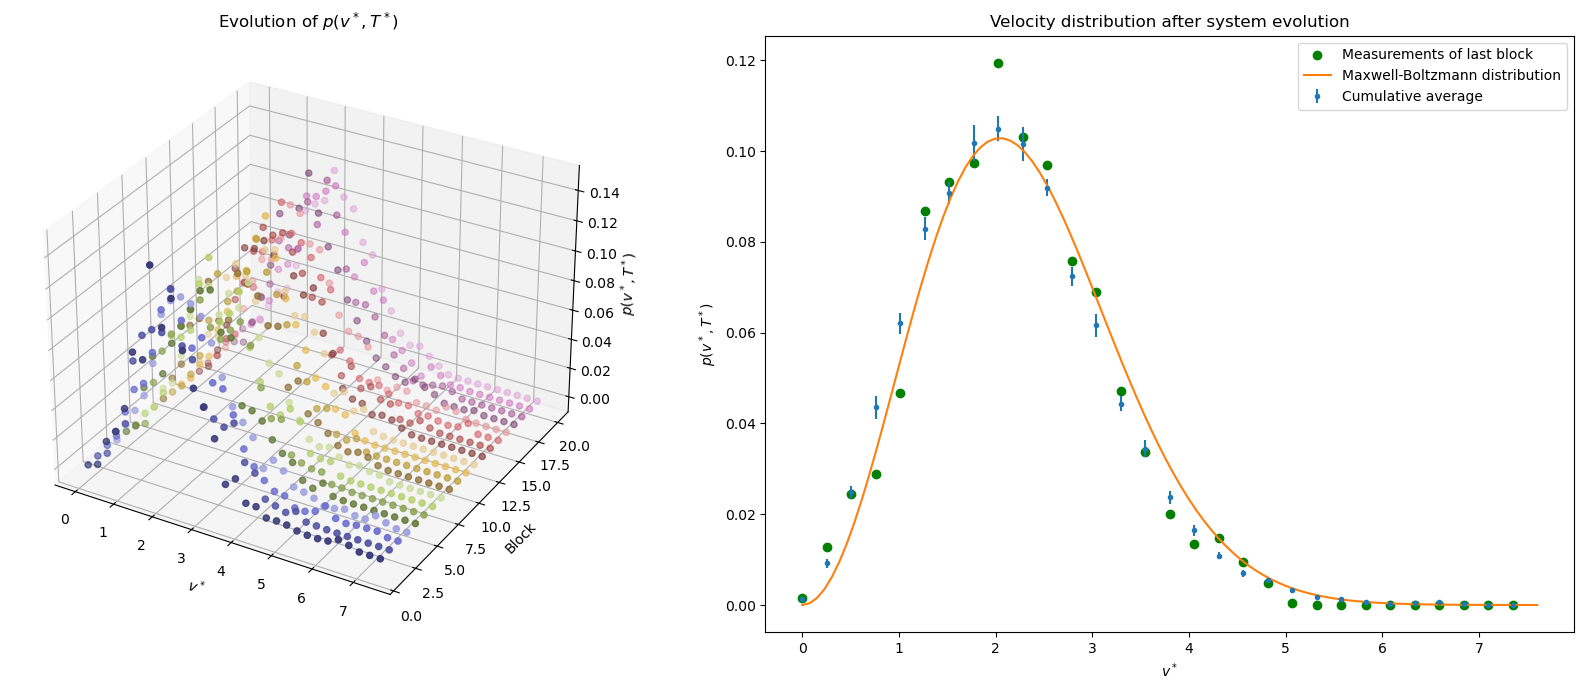

In [29]:
v, pofv, err = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv.dat", unpack=True)
data = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv_blocks.dat", usecols=(0,1,2))
x = np.linspace(v[0], v[-1]+v[1], 100)
T = 2.089

fig = plt.figure(figsize=(17, 7))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[1])
ax.errorbar(v, pofv, err, fmt=".", label="Cumulative average")
ax.scatter(v, data[-v.size:,2], color="green", label="Measurements of last block")
ax.plot(x, np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(x,2)*np.exp(-np.power(x,2)/(2*T))*(v[1]-v[0]), label="Maxwell-Boltzmann distribution")
ax.set_title("Velocity distribution after system evolution")
ax.set_xlabel("$v^*$")
ax.set_ylabel("$p(v^*,T^*)$")
ax.legend()

ax = fig.add_subplot(gs[0], projection="3d")
sc = ax.scatter(data[:,1], data[:,0], data[:,2], c=data[:,0], cmap='tab20b')
ax.set_title("Evolution of $p(v^*,T^*)$")
ax.set_xlabel("$v^*$")
ax.set_ylabel("Block")
ax.set_zlabel("$p(v^*,T^*)$", rotation=90, horizontalalignment='center', verticalalignment='baseline')

fig.tight_layout()
plt.show()

To test the function that calculates $p(v^*,T^*)$ a simulation was run with $T^*=1.9$ ($T_\text{eff}=2.089\pm0.004$), $r_c=5.0$, $N_\text{blocks}=20$ and $N_\text{steps}=2000$. The calculation of the probability distribution function is correct since the result is resembles the Maxwell-Boltzmann distribution. The discrepancies can be explained by the fact that the system was not equilibrated so that the evolution of $p(v^*,T^*)$ could be shown.

## Esercizio 04.2

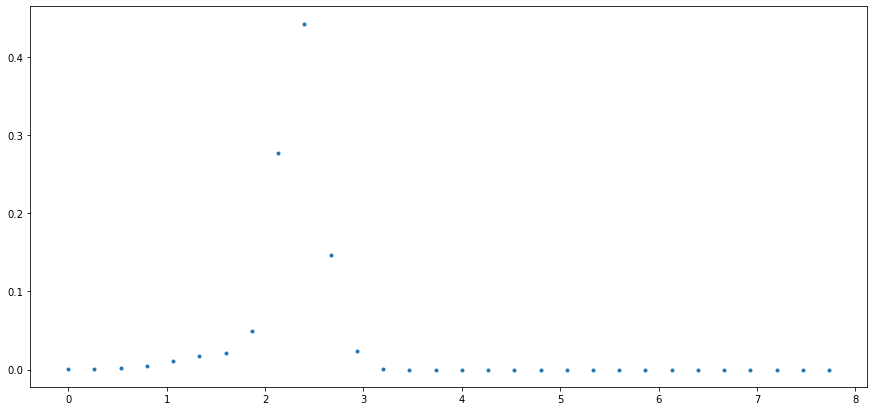

In [ ]:
sigma = 0.34
temp = 120
m = 39.948

data = np.loadtxt("../NSL_SIMULATOR/OUTPUT/pofv_blocks.dat")
n_blocks = int(data[-1,0])
_, n_bins = np.unique(data[:,0], return_counts=True)
n_bins = n_bins[0]

fig, ax = plt.subplots(1, 1, figsize=(15,7))
bins = data[:n_bins,1]
pofv = data[:n_bins,2]
plot, = ax.plot(bins, pofv, ".")

for i in range(1, n_blocks):
    pofv = data[i*n_bins:(i+1)*n_bins,2]
    plot.set_ydata(pofv)
    ax.relim()
    ax.autoscale_view()
    for j in range(10000000):
        pass
    display.display(plt.gcf())
    display.clear_output(wait=True);

AttributeError: 'Figure' object has no attribute 'subplot_adjust'

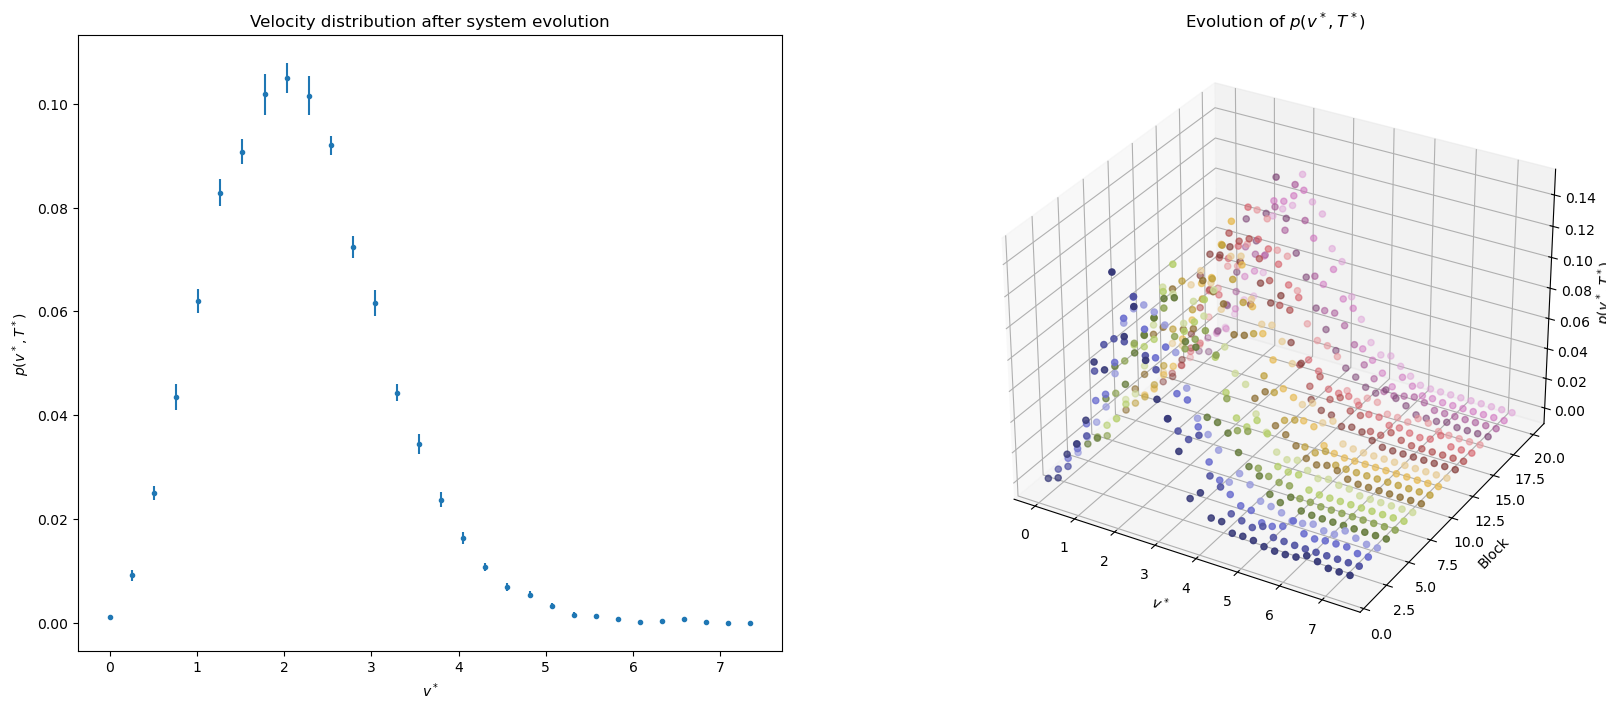

In [ ]:
v, pofv, err = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv.dat", unpack=True)
data = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv_blocks.dat", usecols=(0,1,2))
n_blocks = int(data[-1,0]) # Finds the number of blocks by using the block label of the last measurement
_, n_bins = np.unique(data[:,0], return_counts=True) # Finds the number of bins by counting how many measurements have the same block label

fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[0])
ax.errorbar(v, pofv, err, fmt=".")
ax.set_title("Velocity distribution after system evolution")
ax.set_xlabel("$v^*$")
ax.set_ylabel("$p(v^*,T^*)$");

ax = fig.add_subplot(gs[1], projection="3d")
sc = ax.scatter(data[:,1], data[:,0], data[:,2], c=data[:,0], cmap='tab20b')
ax.set_title("Evolution of $p(v^*,T^*)$")
ax.set_xlabel("$v^*$")
ax.set_ylabel("Block")
ax.set_zlabel("$p(v^*,T^*)$", rotation=90, horizontalalignment='center', verticalalignment='baseline')
ax.dist = 1

#ax = fig.add_subplot(122, projection="3d")
#cb = fig.colorbar(sc, ax=ax, pad=0.12, label='block')

plt.show()

1.000000145

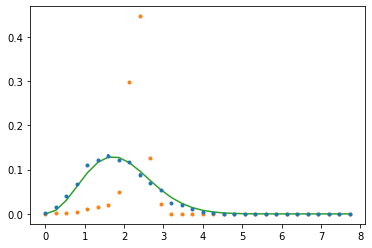

In [ ]:
v, pofv, err = np.loadtxt("../NSL_SIMULATOR/OUTPUT/pofv.dat", unpack=True)
temp = np.loadtxt("../NSL_SIMULATOR/OUTPUT/temperature.dat")[-1,2]


plt.errorbar(v, pofv, err, fmt=".");
plt.plot(v,data[:n_bins,2], ".")
pofv_exp = np.power(2*np.pi*temp, -1.5)*4*np.pi*np.power(v,2)*np.exp(-np.power(v,2)/(2*temp))
plt.plot(v, pofv_exp*(v[1]-v[0]))

np.sum(pofv_exp)*(v[1]-v[0])
np.sum(pofv)

## Esercizio 4.3

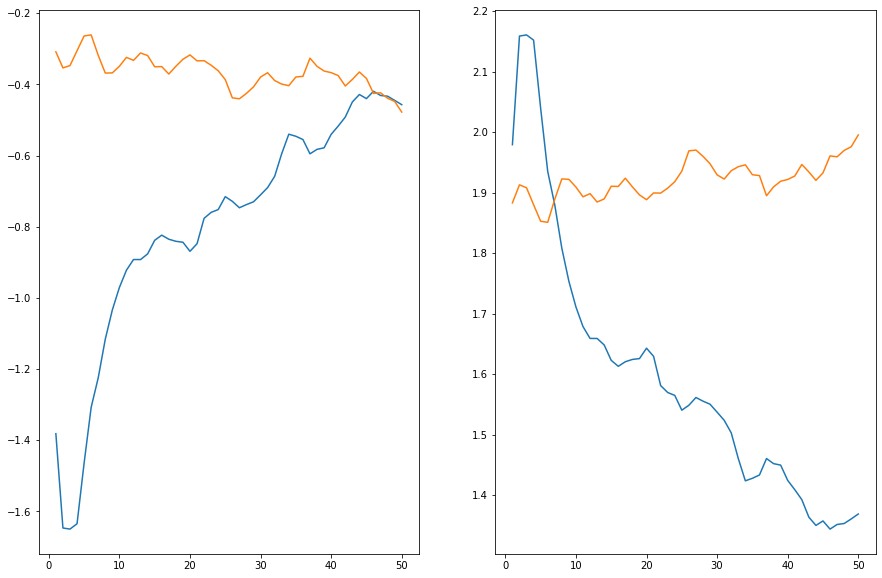

In [ ]:
blocks, pe = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.2_1/potential_energy.dat", usecols=(0,1),unpack=True)
temp = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.2_1/temperature.dat")[:,1]

pe_inverse = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.3_1/potential_energy.dat")[::-1,1]
temp_inverse = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.3_1/temperature.dat")[::-1,1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,10))

ax1.plot(blocks, pe)
ax1.plot(blocks, pe_inverse)

ax2.plot(blocks, temp)
ax2.plot(blocks, temp_inverse)